# Multivariate EDA and PCA: Household Consumption in Mexico

Mexico's 32 states differ dramatically in income, geography, and access to goods and services.
In this tutorial we use **Principal Component Analysis (PCA)** to turn 11 household-level
variables from INEGI's *Encuesta Nacional de Ingresos y Gastos de los Hogares* (ENIGH) into
a clear, interpretable picture of regional well-being.

By the end you'll know how to:
- Explore a multivariate dataset and identify which variables drive dispersion
- Read and interpret a correlation heatmap
- Choose the number of principal components with three criteria
- Build a biplot that places both states and variables in the same reduced space
- Connect statistical patterns to real geographic context

**Data source:** ENIGH (INEGI) — proportion of households with each good or service, by state.
32 observations (states) × 11 variables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
np.random.seed(42)

## The Dataset

Each row is a Mexican state. Each column is the **proportion of households** (0 to 1)
that own or subscribe to a given good or service. The variables span digital access
(internet, cable TV), basic appliances (stove, fridge, washing machine), and regional goods
(air conditioning, car).

We rename the columns to short, clean identifiers before doing any analysis.

In [2]:
# Load data
df = pd.read_excel('Hogares_equipo.xlsx')

# Clean column names
df.columns = ['estado', 'internet', 'television', 'tv_paga', 'telefonia',
               'radio', 'auto', 'lavadora', 'estufa', 'refri', 'micro', 'ac']
df['estado'] = df['estado'].str.strip()   # remove trailing spaces

LABELS = {
    'internet'  : 'Internet',
    'television': 'Televisión',
    'tv_paga'   : 'TV de Paga',
    'telefonia' : 'Telefonía',
    'radio'     : 'Radio',
    'auto'      : 'Automóvil',
    'lavadora'  : 'Lavadora',
    'estufa'    : 'Estufa',
    'refri'     : 'Refrigerador',
    'micro'     : 'Microondas',
    'ac'        : 'Aire Acond.',
}

NUMERIC = list(LABELS.keys())

print(f"Dataset: {df.shape[0]} states × {len(NUMERIC)} variables")
df.head()

Dataset: 32 states × 11 variables


,estado,internet,television,tv_paga,telefonia,radio,auto,lavadora,estufa,refri,micro,ac
0,Aguascalientes,0.4708,0.9626,0.6428,0.9500,0.7936,0.3694,0.8142,0.9481,0.9119,0.5424,0.0103
1,Baja California,0.6658,0.9314,0.6158,0.9440,0.5722,0.5085,0.7912,0.9707,0.9452,0.6420,0.3290
2,Baja California Sur,0.7577,0.9207,0.7581,0.9756,0.5170,0.4320,0.6562,0.9380,0.9066,0.4917,0.4740
3,Campeche,0.5308,0.9151,0.7658,0.8528,0.3884,0.2170,0.7626,0.8394,0.8436,0.3423,0.2780
4,Coahuila,0.5165,0.9562,0.6077,0.9348,0.6575,0.3516,0.8176,0.9696,0.9550,0.5668,0.2976


### Variable types

| Variable | Type | Scale |
|---|---|---|
| Estado | Categorical | Nominal |
| Internet, Televisión, TV de Paga, Telefonía, Radio, Automóvil, Lavadora, Estufa, Refrigerador, Microondas, Aire Acond. | Numeric | Ratio (proportions 0–1) |

All numeric variables are proportions, so they're already on a comparable scale in terms of
units — but their *spread* and *mean* differ substantially, which is exactly what we want to explore.

## Exploratory Data Analysis

### Which goods vary the most across states?

The first question in any EDA is: where is the action? Let's visualize all 11 variables
across all 32 states at once using a facet plot. Each panel shows one variable, with states
on the x-axis and proportion on the y-axis.

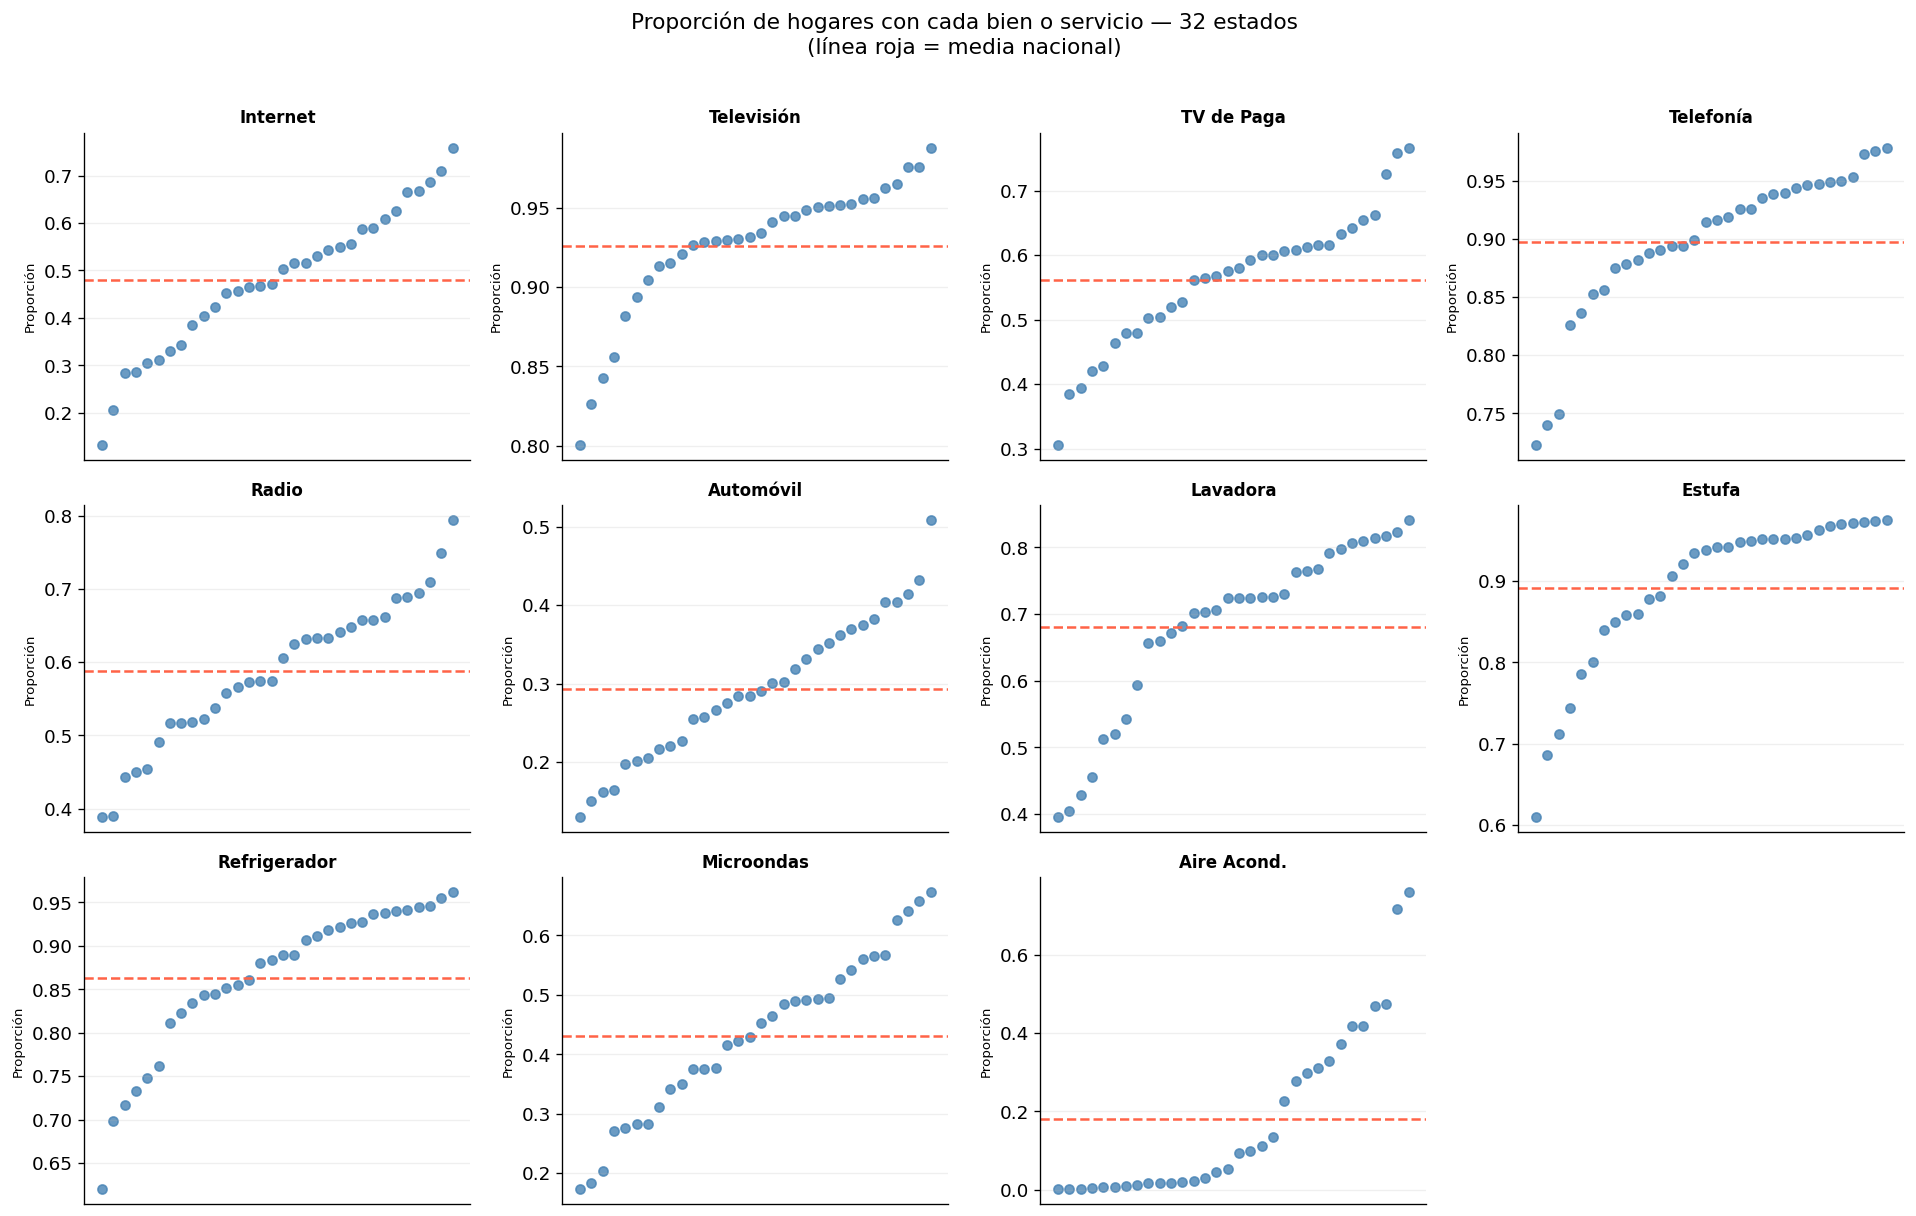

In [3]:
df_long = df.melt(id_vars='estado', var_name='variable', value_name='proporcion')
df_long['variable_label'] = df_long['variable'].map(LABELS)

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for i, (var, label) in enumerate(LABELS.items()):
    ax = axes[i]
    subset = df_long[df_long['variable'] == var].sort_values('proporcion')
    ax.scatter(range(len(subset)), subset['proporcion'],
               color='steelblue', s=30, alpha=0.8)
    ax.axhline(subset['proporcion'].mean(), color='tomato', linewidth=1.5, linestyle='--')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.set_ylabel('Proporción', fontsize=8)
    ax.grid(True, alpha=0.2)

axes[-1].set_visible(False)  # hide unused panel

fig.suptitle('Proporción de hogares con cada bien o servicio — 32 estados\n(línea roja = media nacional)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_facets.png', bbox_inches='tight', dpi=150)
plt.show()

Notice the stark differences in spread:

- **Televisión** and **Telefonía** are near-universal with very little variation — almost everyone has them.
- **Aire Acondicionado** and **Internet** show the widest spread: some states have virtually none,
  others have well over half of households covered.
- **Radio** sits in the middle but with an interesting pattern — we'll revisit this in the biplot.

Let's quantify the spread with summary statistics.

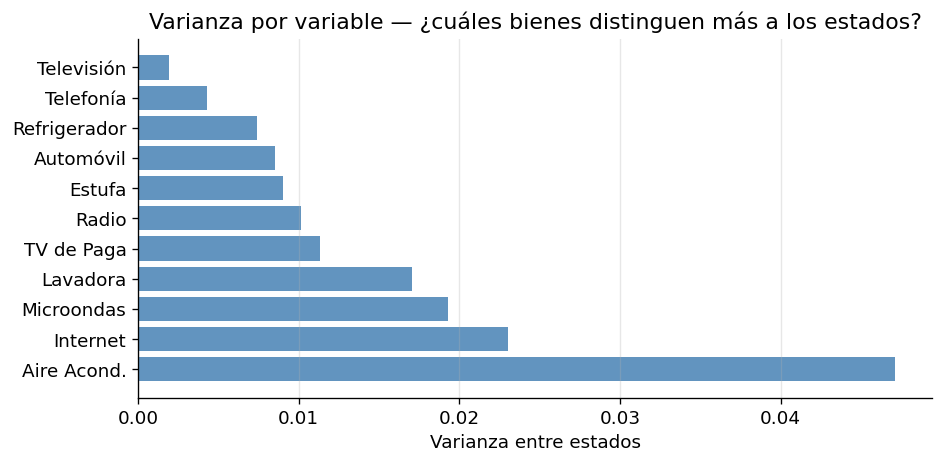

               Media  Desv. Estándar  Varianza
Aire Acond.   0.1804          0.2170    0.0471
Internet      0.4793          0.1518    0.0230
Microondas    0.4314          0.1389    0.0193
Lavadora      0.6807          0.1305    0.0170
TV de Paga    0.5609          0.1063    0.0113
Radio         0.5872          0.1006    0.0101
Estufa        0.8918          0.0951    0.0090
Automóvil     0.2935          0.0922    0.0085
Refrigerador  0.8632          0.0861    0.0074
Telefonía     0.8973          0.0653    0.0043
Televisión    0.9258          0.0435    0.0019


In [4]:
stats = df[NUMERIC].agg(['mean', 'std', 'var']).T
stats.columns = ['Media', 'Desv. Estándar', 'Varianza']
stats.index = [LABELS[c] for c in stats.index]
stats = stats.sort_values('Varianza', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(stats.index, stats['Varianza'], color='steelblue', alpha=0.85)
ax.set_xlabel('Varianza entre estados')
ax.set_title('Varianza por variable — ¿cuáles bienes distinguen más a los estados?')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(stats.round(4).to_string())

### Outliers: states that break the pattern

A boxplot with individual state labels makes it easy to spot which states are consistently
out of step with the rest. We expect states in Mexico's south (Chiapas, Oaxaca, Guerrero)
and states with extreme climates to stand out.

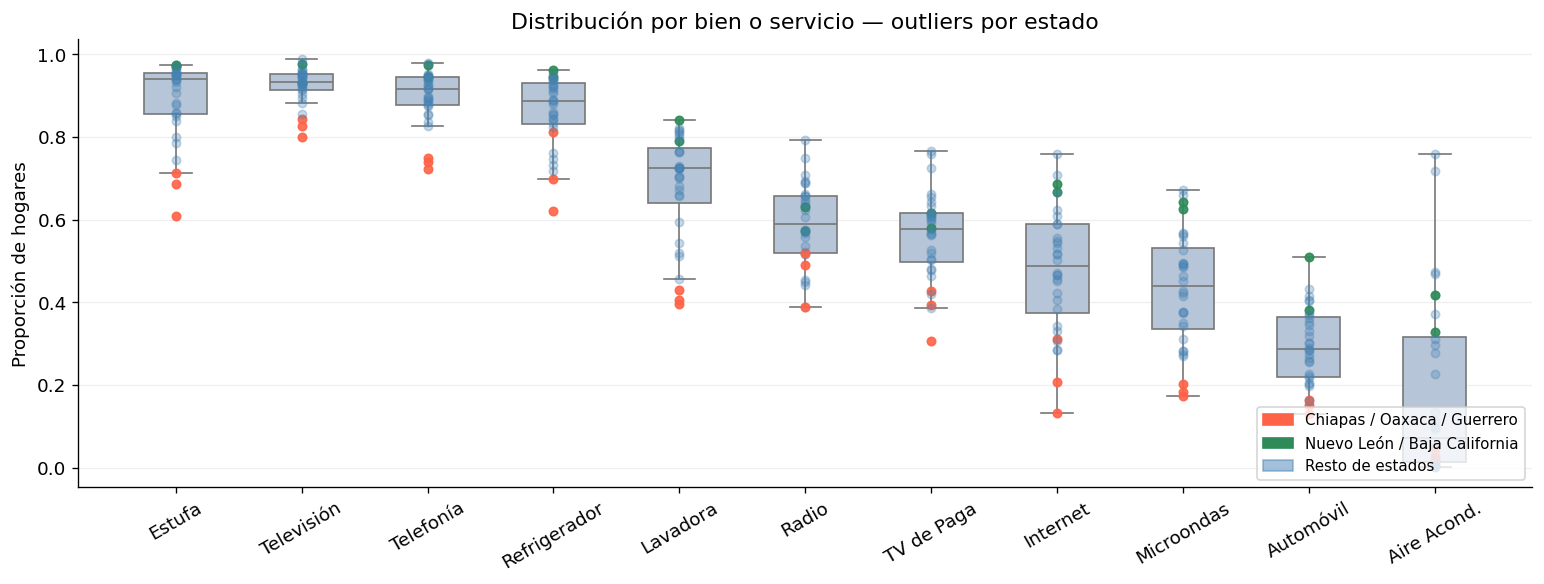

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

# Reorder variables by median for a cleaner visual
var_order = df[NUMERIC].median().sort_values(ascending=False).index.tolist()
label_order = [LABELS[v] for v in var_order]

df_plot = df_long.copy()
df_plot['variable_label'] = pd.Categorical(
    df_plot['variable_label'],
    categories=label_order, ordered=True
)

sns.boxplot(data=df_plot, x='variable_label', y='proporcion',
            color='lightsteelblue', width=0.5, ax=ax, fliersize=0)

# Overlay scatter — color outlier states
highlight = {'Chiapas': 'tomato', 'Oaxaca': 'tomato', 'Guerrero': 'tomato',
             'Nuevo León': 'seagreen', 'Baja California': 'seagreen'}

for _, row in df_long.iterrows():
    label = LABELS[row['variable']]
    x_pos = label_order.index(label)
    color = highlight.get(row['estado'], 'steelblue')
    alpha = 0.9 if row['estado'] in highlight else 0.3
    ax.scatter(x_pos, row['proporcion'], color=color, s=25, alpha=alpha, zorder=3)

# Legend
patches = [mpatches.Patch(color='tomato', label='Chiapas / Oaxaca / Guerrero'),
           mpatches.Patch(color='seagreen', label='Nuevo León / Baja California'),
           mpatches.Patch(color='steelblue', alpha=0.5, label='Resto de estados')]
ax.legend(handles=patches, fontsize=9, loc='lower right')

ax.set_xlabel('')
ax.set_ylabel('Proporción de hogares')
ax.set_title('Distribución por bien o servicio — outliers por estado')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

The three southern states — **Chiapas, Oaxaca, and Guerrero** — consistently appear below
the median across nearly every variable. This isn't random: these states have the lowest
per-capita income in Mexico and the highest proportion of rural and indigenous households.

At the other end, **Nuevo León** stands out particularly for **Aire Acondicionado** (above 50%),
driven by its hot northern climate rather than higher income alone. **Baja California** follows
a similar pattern.

This geographic logic is exactly what PCA will help us formalize.

### Are there states with similar overall behavior?

Before jumping into PCA, let's look at a simple average across all goods. This won't capture
the structure we want (it treats all variables equally regardless of variance), but it gives
us an intuitive anchor.

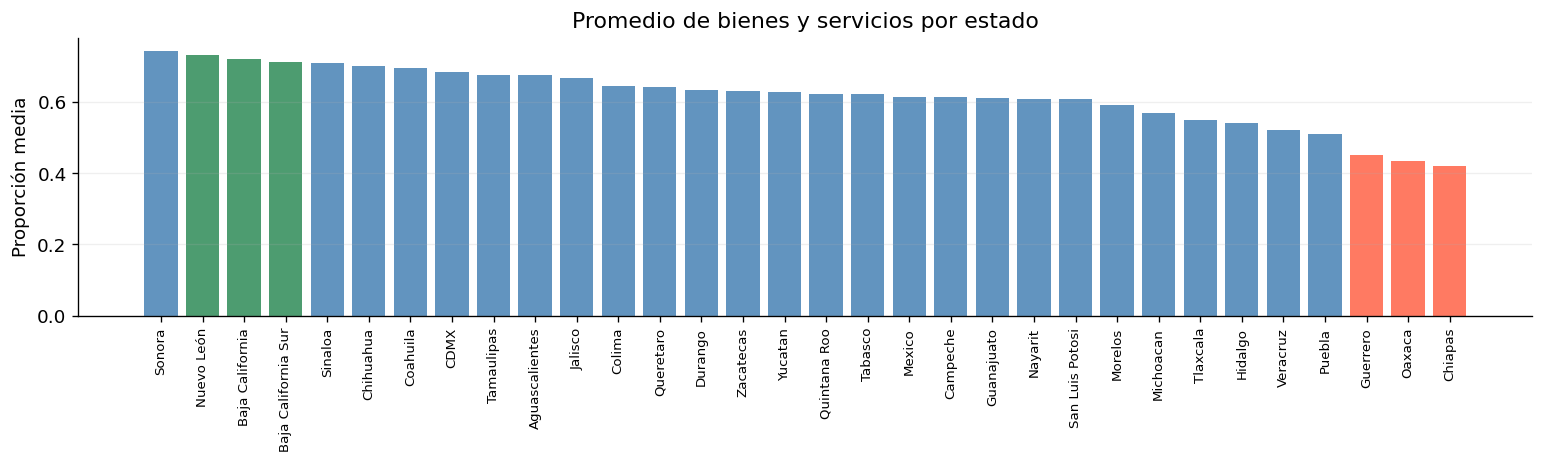

Estados con mayor proporción media:
estado
Sonora                 0.743
Nuevo León             0.732
Baja California        0.720
Baja California Sur    0.712
Sinaloa                0.708

Estados con menor proporción media:
estado
Veracruz    0.520
Puebla      0.509
Guerrero    0.450
Oaxaca      0.433
Chiapas     0.420


In [6]:
state_mean = df_long.groupby('estado')['proporcion'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
colors_bar = ['tomato' if s in ['Chiapas', 'Oaxaca', 'Guerrero']
              else 'seagreen' if s in ['Nuevo León', 'Baja California', 'Baja California Sur']
              else 'steelblue' for s in state_mean.index]
ax.bar(state_mean.index, state_mean.values, color=colors_bar, alpha=0.85)
ax.set_xticklabels(state_mean.index, rotation=90, fontsize=8)
ax.set_ylabel('Proporción media')
ax.set_title('Promedio de bienes y servicios por estado')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

print("Estados con mayor proporción media:")
print(state_mean.head(5).round(3).to_string())
print("\nEstados con menor proporción media:")
print(state_mean.tail(5).round(3).to_string())

## Correlation Matrix

PCA works best when variables are correlated — it "compresses" correlated variables into
fewer dimensions without losing much information. Let's check the correlation structure first.

A high correlation between two variables means PCA will likely combine them into a single
component. Variables that are uncorrelated (or negatively correlated) will end up on
different axes.

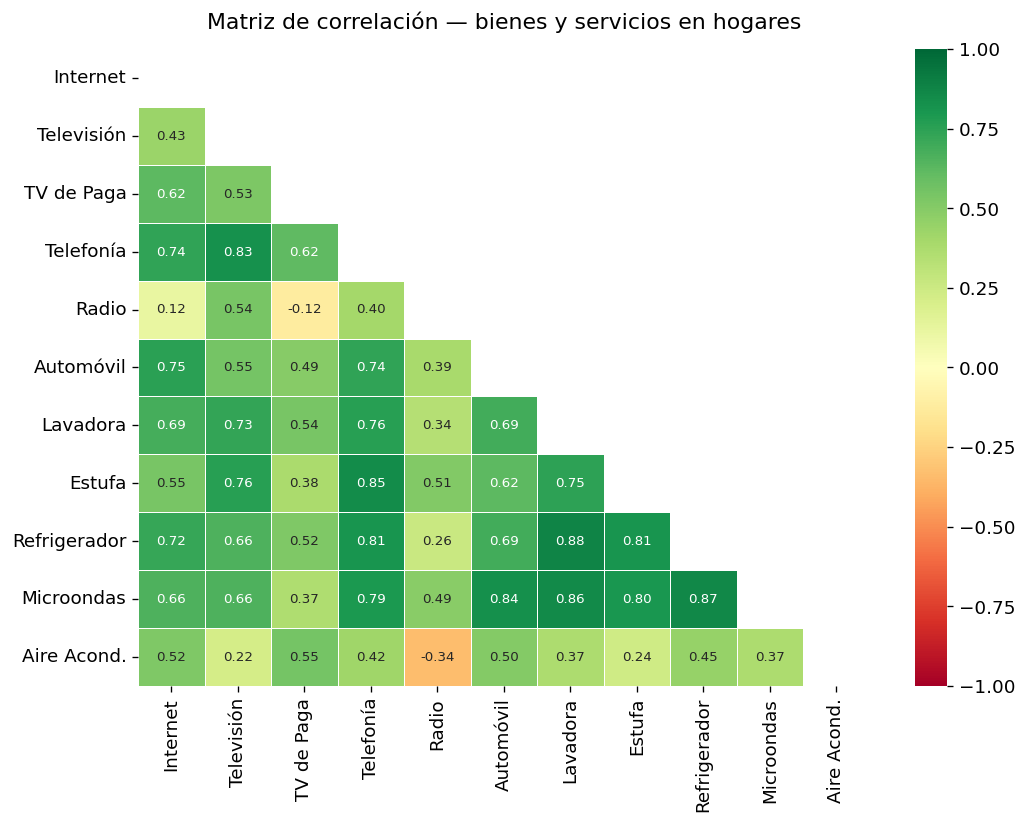

In [7]:
corr = df[NUMERIC].corr()
labels_corr = [LABELS[c] for c in NUMERIC]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

sns.heatmap(corr, mask=mask,
            annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0,
            xticklabels=labels_corr, yticklabels=labels_corr,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})

ax.set_title('Matriz de correlación — bienes y servicios en hogares', pad=12)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

**What to notice:**

- **Appliances cluster together**: `Estufa`, `Refrigerador`, `Lavadora`, and `Microondas`
  are highly correlated (r > 0.7). In Mexico, households tend to acquire these goods together
  as income rises — they represent a "basic comfort" bundle.

- **Digital services form a second cluster**: `Internet`, `TV de Paga` correlate moderately
  with each other and with the appliance cluster.

- **Aire Acondicionado is the odd one out**: low or negative correlation with most other
  variables. This makes sense — AC ownership depends more on regional climate (northern heat)
  than on income per se.

- **Radio** shows weak correlations throughout — it's becoming a legacy good, and its
  presence in a household signals something different from the rest.

This structure — two clusters plus two "independent" variables — is exactly what PCA will
extract.

## Principal Component Analysis (PCA)

PCA finds new axes (principal components) that capture the maximum variance in the data.
The first component PC1 points in the direction of greatest spread; PC2 is orthogonal to it
and captures the next most variance, and so on.

Before applying PCA, we **standardize** the data (zero mean, unit variance). This is
critical when variables have different scales or ranges — otherwise, high-variance variables
dominate simply because of their units. Here all variables are proportions, so the
difference is moderate, but standardization is still best practice.

### Is this dataset suitable for PCA?

Two conditions should hold:
1. **Variables are correlated** — confirmed by the heatmap above
2. **The KMO statistic is adequate** — measures the proportion of variance that is common
   across variables (i.e., not unique noise)

In [8]:
# Standardize
scaler = StandardScaler()
X_std = scaler.fit_transform(df[NUMERIC])

# KMO test
kmo_per_var, kmo_overall = calculate_kmo(X_std)

kmo_df = pd.DataFrame({
    'Variable': [LABELS[c] for c in NUMERIC],
    'KMO': kmo_per_var
}).sort_values('KMO', ascending=False)

def kmo_label(k):
    if k >= 0.90: return 'Excelente'
    if k >= 0.80: return 'Bueno'
    if k >= 0.70: return 'Aceptable'
    if k >= 0.60: return 'Mediocre'
    return 'Malo'

kmo_df['Criterio'] = kmo_df['KMO'].apply(kmo_label)

print(f"KMO global: {kmo_overall:.4f}  →  {kmo_label(kmo_overall)}")
print()
print(kmo_df.to_string(index=False))

KMO global: 0.8080  →  Bueno

    Variable      KMO  Criterio
      Estufa 0.905860 Excelente
Refrigerador 0.897605     Bueno
  TV de Paga 0.841203     Bueno
    Lavadora 0.825819     Bueno
   Automóvil 0.816045     Bueno
   Telefonía 0.806478     Bueno
  Microondas 0.792236 Aceptable
 Aire Acond. 0.777277 Aceptable
    Internet 0.755041 Aceptable
  Televisión 0.747580 Aceptable
       Radio 0.616213  Mediocre


A KMO of **0.81 (Good)** tells us the data is well-suited for PCA — there's enough shared
variance across variables to justify dimension reduction. Variables like `Estufa` and
`Refrigerador` reach 0.90+ (Excellent), meaning almost all their variance is shared with
others — they'll be easy for PCA to summarize.

### Criterion 1 — Cumulative Explained Variance (≥ 75%)

Fit PCA and examine how many components are needed to explain at least 75% of total variance.

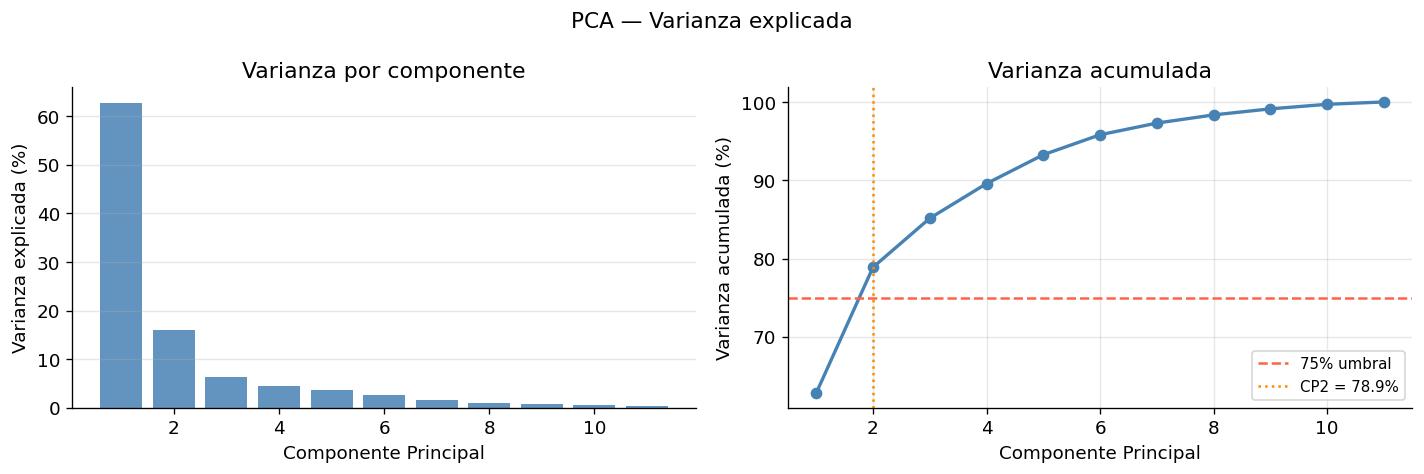

Varianza explicada por componente:
  PC1: 62.8%  (acumulado: 62.8%)
  PC2: 16.1%  (acumulado: 78.9%) ← 75% alcanzado
  PC3: 6.3%  (acumulado: 85.1%)
  PC4: 4.4%  (acumulado: 89.6%)
  PC5: 3.7%  (acumulado: 93.3%)
  PC6: 2.6%  (acumulado: 95.8%)
  PC7: 1.5%  (acumulado: 97.3%)
  PC8: 1.0%  (acumulado: 98.3%)
  PC9: 0.8%  (acumulado: 99.1%)
  PC10: 0.6%  (acumulado: 99.7%)
  PC11: 0.3%  (acumulado: 100.0%)


In [9]:
pca = PCA()
scores = pca.fit_transform(X_std)
ev = pca.explained_variance_ratio_
cumev = np.cumsum(ev)

n_75 = np.argmax(cumev >= 0.75) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual variance
axes[0].bar(range(1, len(ev)+1), ev * 100, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza por componente')
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative
axes[1].plot(range(1, len(cumev)+1), cumev * 100, 'o-',
             color='steelblue', linewidth=2, markersize=6)
axes[1].axhline(75, color='tomato', linestyle='--', linewidth=1.5, label='75% umbral')
axes[1].axvline(n_75, color='darkorange', linestyle=':', linewidth=1.5,
                label=f'CP{n_75} = {cumev[n_75-1]*100:.1f}%')
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA — Varianza explicada', fontsize=13)
plt.tight_layout()
plt.savefig('pca_variance.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Varianza explicada por componente:")
for i, (e, c) in enumerate(zip(ev, cumev)):
    marker = ' ← 75% alcanzado' if i+1 == n_75 else ''
    print(f"  PC{i+1}: {e*100:.1f}%  (acumulado: {c*100:.1f}%){marker}")

**Result:** The first **2 components** explain **78.9%** of total variance — well above the
75% threshold. PC1 alone captures 62.8%, which is unusually high and signals a strong
single dominant factor (we'll see it's the general development/income axis).

### Criterion 2 — Scree Plot (Elbow Method)

The scree plot shows the eigenvalue (variance) of each component. We look for the "elbow"
— the point where adding another component yields diminishing returns.

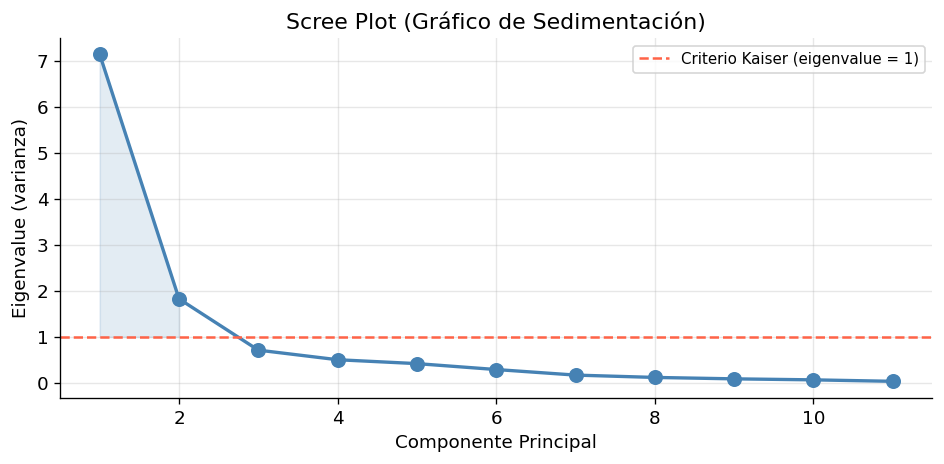

In [10]:
eigenvalues = pca.explained_variance_

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-',
        color='steelblue', linewidth=2, markersize=8)
ax.axhline(1, color='tomato', linestyle='--', linewidth=1.5, label='Criterio Kaiser (eigenvalue = 1)')
ax.fill_between(range(1, len(eigenvalues)+1), eigenvalues, 1,
                where=(eigenvalues > 1), alpha=0.15, color='steelblue')
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Eigenvalue (varianza)')
ax.set_title('Scree Plot (Gráfico de Sedimentación)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scree_plot.png', bbox_inches='tight', dpi=150)
plt.show()

The elbow is clearly at **PC2**: the drop from PC1 to PC2 is steep, and after PC2
the decrease flattens. The Kaiser rule (eigenvalue > 1) also selects exactly 2 components.

All three criteria agree: **2 components** is the right choice for this dataset.

| Criterion | Components selected |
|---|---|
| Cumulative variance ≥ 75% | **2** (78.9%) |
| Scree plot (elbow) | **2** |
| Kaiser (eigenvalue > 1) | **2** |

## The Biplot: States and Variables in the Same Space

A biplot overlays two things on the same 2D plot:
1. **Points** — one per state, positioned by their PC1 and PC2 scores
2. **Arrows** — one per variable, showing how each variable loads onto the two components

The closer two arrows point in the same direction, the more correlated those variables are.
An arrow pointing left vs. right tells you whether a variable is associated with states on
the left or right side of the plot (and same for up/down).

States near the tip of an arrow score high on that variable.

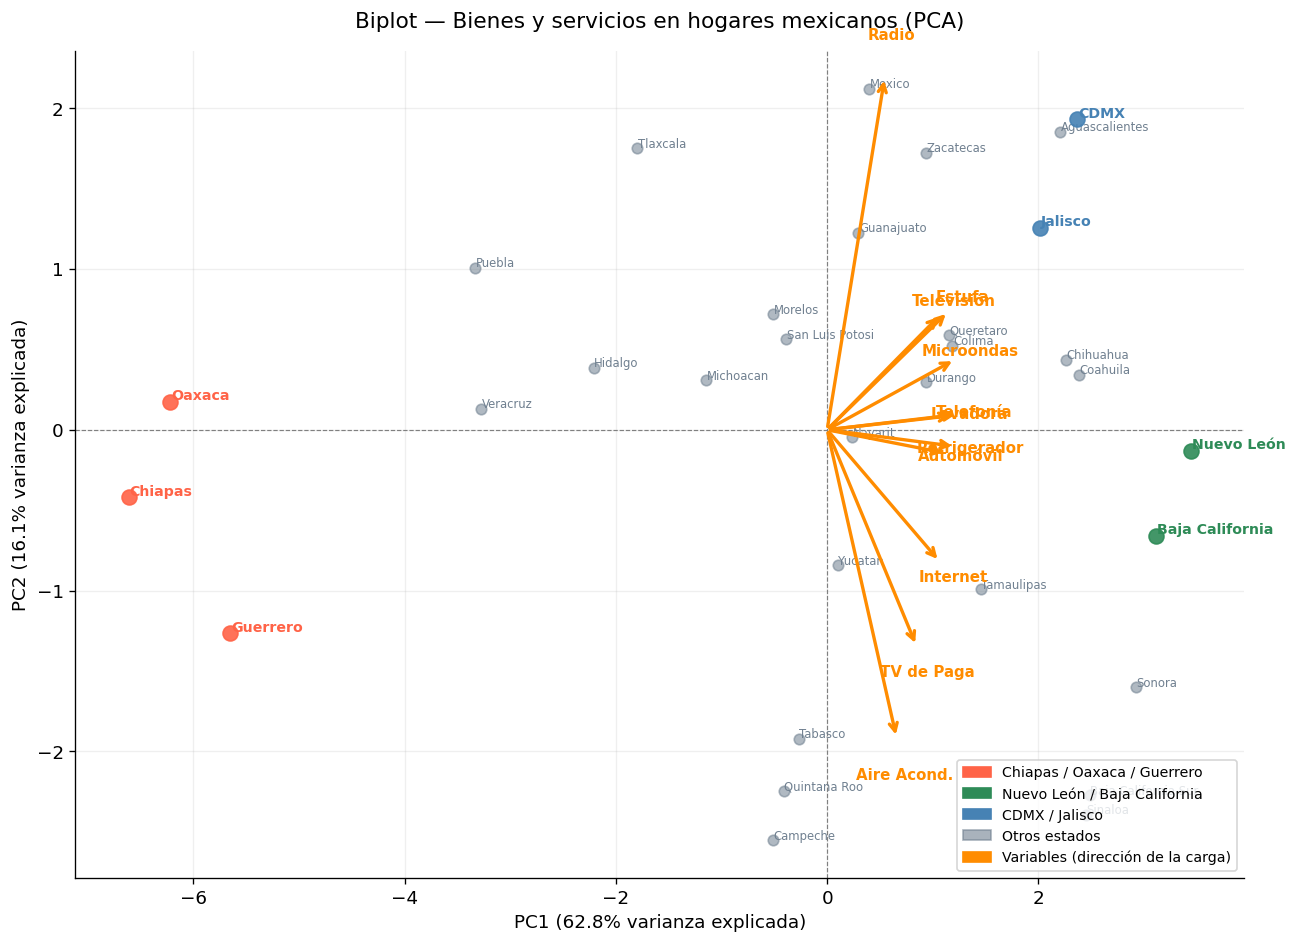

In [11]:
loadings = pca.components_   # shape: (n_components, n_features)

fig, ax = plt.subplots(figsize=(11, 8))

# ── State scores ──────────────────────────────────────────────────
highlight_states = {
    'Chiapas': 'tomato', 'Oaxaca': 'tomato', 'Guerrero': 'tomato',
    'Nuevo León': 'seagreen', 'Baja California': 'seagreen',
    'CDMX': 'steelblue', 'Jalisco': 'steelblue',
}

for i, estado in enumerate(df['estado']):
    color = highlight_states.get(estado, 'slategrey')
    alpha = 0.9 if estado in highlight_states else 0.55
    size  = 80 if estado in highlight_states else 40
    ax.scatter(scores[i, 0], scores[i, 1], color=color, s=size,
               alpha=alpha, zorder=3)
    offset = (0.05, 0.08) if estado not in highlight_states else (0.07, 0.12)
    ax.annotate(estado, (scores[i, 0], scores[i, 1]),
                fontsize=7 if estado not in highlight_states else 8.5,
                color=color,
                xytext=offset, textcoords='offset fontsize',
                fontweight='bold' if estado in highlight_states else 'normal')

# ── Variable loadings (arrows) ────────────────────────────────────
scale = 3.5   # scale arrows to match score cloud
for j, var in enumerate(NUMERIC):
    lx = loadings[0, j] * scale
    ly = loadings[1, j] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='darkorange',
                                lw=2.0, mutation_scale=12))
    ax.text(lx * 1.12, ly * 1.12, LABELS[var],
            color='darkorange', fontsize=9, fontweight='bold',
            ha='center', va='center')

# ── Reference lines ───────────────────────────────────────────────
ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.7, linestyle='--')

# ── Legend ───────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color='tomato',    label='Chiapas / Oaxaca / Guerrero'),
    mpatches.Patch(color='seagreen',  label='Nuevo León / Baja California'),
    mpatches.Patch(color='steelblue', label='CDMX / Jalisco'),
    mpatches.Patch(color='slategrey', alpha=0.6, label='Otros estados'),
    mpatches.Patch(color='darkorange', label='Variables (dirección de la carga)'),
]
ax.legend(handles=legend_elements, fontsize=8.5, loc='lower right')

ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% varianza explicada)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% varianza explicada)', fontsize=11)
ax.set_title('Biplot — Bienes y servicios en hogares mexicanos (PCA)', fontsize=13, pad=14)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('biplot.png', bbox_inches='tight', dpi=150)
plt.show()

### Reading the biplot

**PC1 (horizontal axis, 62.8%)** is the general development axis:
- States on the **right** (Nuevo León, Baja California, Sonora) have high proportions across
  most goods and services.
- States on the **left** (Chiapas, Oaxaca, Guerrero) have low proportions across the board.
- Almost all arrows point to the **right**, confirming that PC1 captures shared growth —
  households that have more income tend to acquire all goods roughly together.

**PC2 (vertical axis, 16.1%)** separates two types of goods:
- **Aire Acondicionado** points sharply **upward** — states like Nuevo León and Baja California
  score high on PC2 because of their hot climate, not just income.
- **Radio** points **downward** — states that still have high radio penetration tend to be
  those where other digital goods haven't fully displaced it.
- **Televisión** and **Telefonía** are nearly horizontal (low PC2 loading), meaning they add
  almost no information beyond the income axis — near-universal goods don't help
  differentiate states.

**Variable relationships:**
- The `Estufa`, `Refri`, `Lavadora`, `Micro` arrows cluster tightly → high correlations (confirmed by the heatmap)
- `Internet` and `TV de Paga` point in a similar direction → digital service bundle
- `AC` and `Radio` point in nearly **opposite vertical directions** → states with lots of AC
  tend to have less radio, and vice versa

**State clusters:**
- **Chiapas, Oaxaca, Guerrero** are far left — structural underdevelopment across all goods
- **Nuevo León, Baja California Sur** are far right AND up — high income + warm climate
- **CDMX and Jalisco** are to the right but low on PC2 — high development, cool climate (no AC)
- **Aguascalientes, Zacatecas** cluster near the center — average on both dimensions

### Confirming state comparisons

Let's verify the visual groupings we see in the biplot with actual numbers.

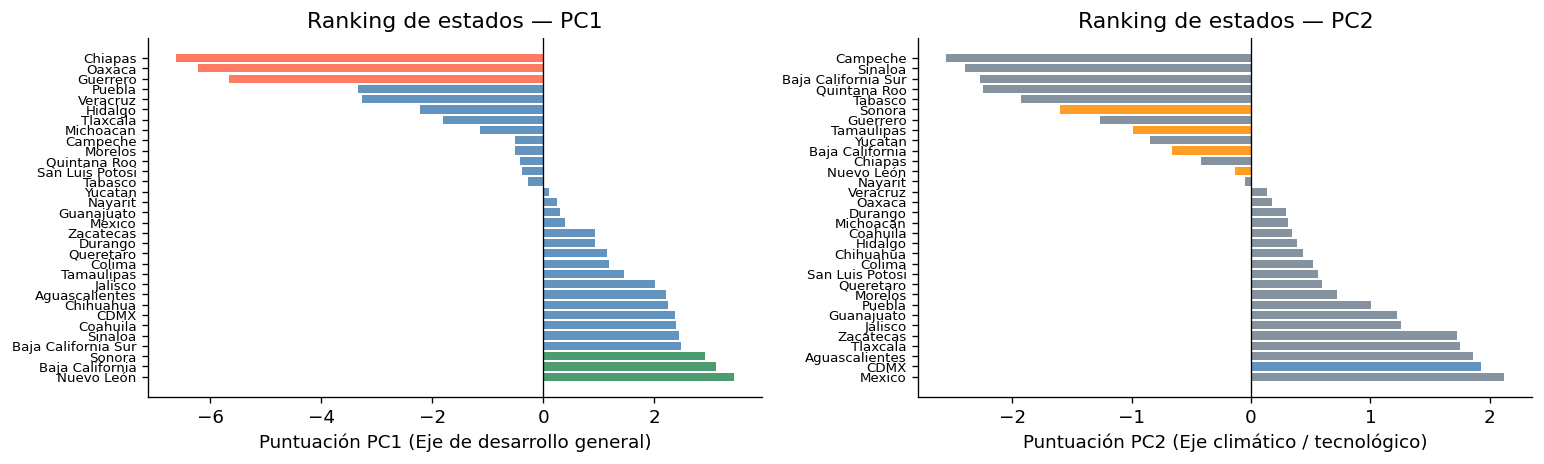

In [12]:
# PC scores for key states
score_df = pd.DataFrame(scores[:, :2], columns=['PC1', 'PC2'])
score_df['estado'] = df['estado'].values
score_df = score_df.sort_values('PC1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PC1 ranking
colors_rank = ['tomato' if s in ['Chiapas', 'Oaxaca', 'Guerrero']
               else 'seagreen' if s in ['Nuevo León', 'Baja California', 'Sonora']
               else 'steelblue' for s in score_df['estado']]

axes[0].barh(score_df['estado'], score_df['PC1'],
             color=colors_rank, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Puntuación PC1 (Eje de desarrollo general)')
axes[0].set_title('Ranking de estados — PC1')
axes[0].tick_params(axis='y', labelsize=8)

# PC2 ranking
score_df_pc2 = score_df.sort_values('PC2', ascending=False)
colors_pc2 = ['darkorange' if s in ['Nuevo León', 'Baja California', 'Sonora', 'Tamaulipas']
              else 'steelblue' if s == 'CDMX'
              else 'slategrey' for s in score_df_pc2['estado']]

axes[1].barh(score_df_pc2['estado'], score_df_pc2['PC2'],
             color=colors_pc2, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Puntuación PC2 (Eje climático / tecnológico)')
axes[1].set_title('Ranking de estados — PC2')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

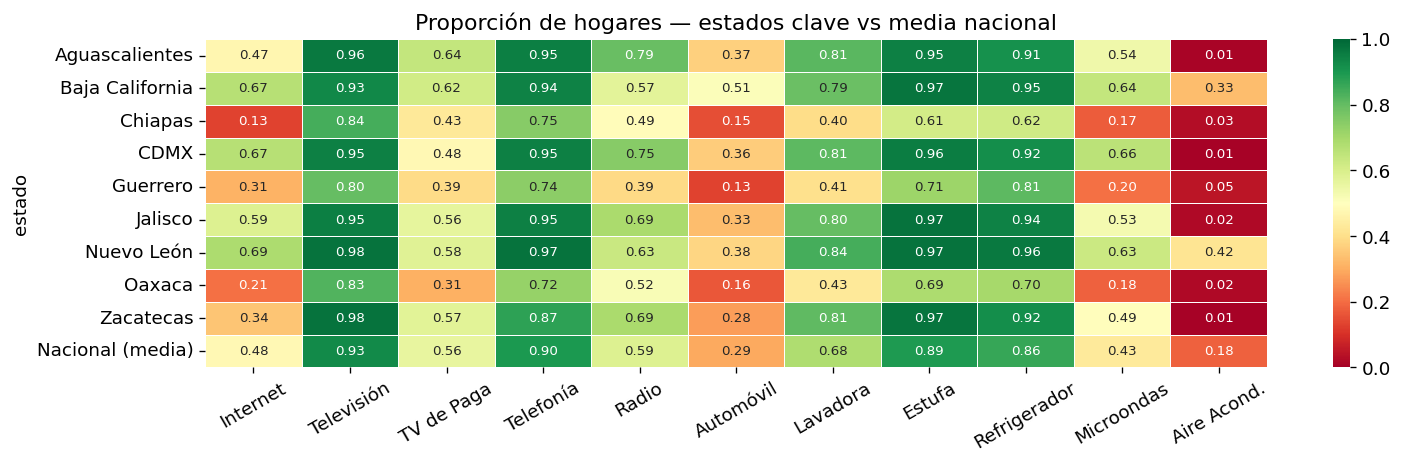

In [13]:
# Numeric comparison — key states as a heatmap
key_states = ['Nuevo León', 'Baja California', 'CDMX', 'Jalisco',
              'Aguascalientes', 'Zacatecas', 'Chiapas', 'Oaxaca', 'Guerrero']

comparison = df[df['estado'].isin(key_states)].set_index('estado').copy()
comparison.columns = [LABELS[c] for c in comparison.columns]
comparison.loc['Nacional (media)'] = df[NUMERIC].mean().values

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(comparison, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Proporción de hogares — estados clave vs media nacional')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## Conclusions

PCA distilled 11 correlated variables into **2 interpretable dimensions** that together
explain **78.9%** of the variance in Mexican household consumption patterns.

**What PC1 tells us** (62.8% of variance): there is a single dominant axis of household
well-being in Mexico. States differ primarily in their *overall access level* to goods and
services. This axis tracks closely with per-capita income — which is why Nuevo León and
Baja California sit on the right while Chiapas, Oaxaca, and Guerrero sit on the left.

**What PC2 tells us** (16.1% of variance): once you control for income, the next biggest
source of variation is *climate and technology transition*. Northern states have high AC
penetration not just because they are richer, but because they need it. Radio still has an
interesting negative loading — it remains more present in states where digital media hasn't
fully taken over.

**Practical takeaways for multivariate analysis:**

| Decision | Recommendation |
|---|---|
| How many PCA components? | Combine cumulative variance (≥75%), scree plot, and Kaiser rule — they rarely disagree |
| Should I standardize before PCA? | Yes, always — even when variables have the same units |
| How do I know PCA is appropriate? | Check KMO ≥ 0.6 and confirm correlations exist in the heatmap |
| What does a biplot tell me? | Arrow direction = high scores on that variable; arrow length = importance; angle between arrows = correlation |

The full code and data are available at:
[github.com/ivandeluna/data-science-notebooks](https://github.com/ivandeluna/data-science-notebooks) — folder `08-metodos-multivariados/`